In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['weg_auf_dem_damm'].sum())
header = 'weg_auf_dem_damm'

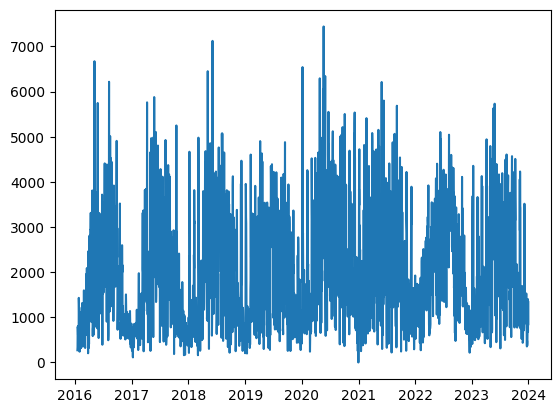

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

In [4]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [5]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [6]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,11869,23015,29352,54468,79024,60993,81692,87663,84065,41612,28292,23934
2017,18008,24753,56283,53761,82494,84145,79828,76622,56736,51711,32452,18985
2018,35301,34888,44342,77264,84989,83996,89846,79888,66785,57766,44290,39963
2019,37637,56834,51555,64308,69258,80132,73185,72930,62131,56763,40105,36497
2020,48837,42524,70775,87026,106173,89296,101008,85966,87758,62562,61009,55000
2021,48952,66794,64322,69441,69407,78057,71890,75410,78844,55991,43001,43947
2022,35318,36940,71179,57529,83816,84423,89542,104557,68660,67642,48737,24756
2023,40515,46296,55101,66552,88403,86726,68547,83681,76247,55518,45167,37100


Monatlich


In [7]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     34554.625
2     41505.500
3     55363.625
4     66293.625
5     82945.500
6     80971.000
7     81942.250
8     83339.625
9     72653.250
10    56195.625
11    42881.625
12    35022.750
Name: weg_auf_dem_damm, dtype: float64


In [8]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [9]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [10]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,weg_auf_dem_damm
year-month,,
2016-01-01,2016-01-01,11869
2016-02-01,2016-02-01,23015
2016-03-01,2016-03-01,29352
2016-04-01,2016-04-01,54468
2016-05-01,2016-05-01,79024
...,...,...
2023-08-01,2023-08-01,83681
2023-09-01,2023-09-01,76247
2023-10-01,2023-10-01,55518


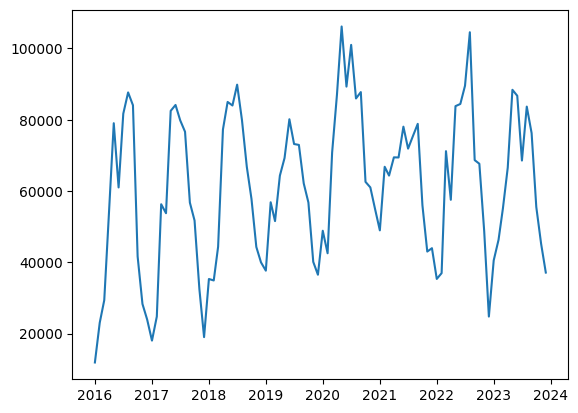

In [11]:
plt.plot(df_month[header])

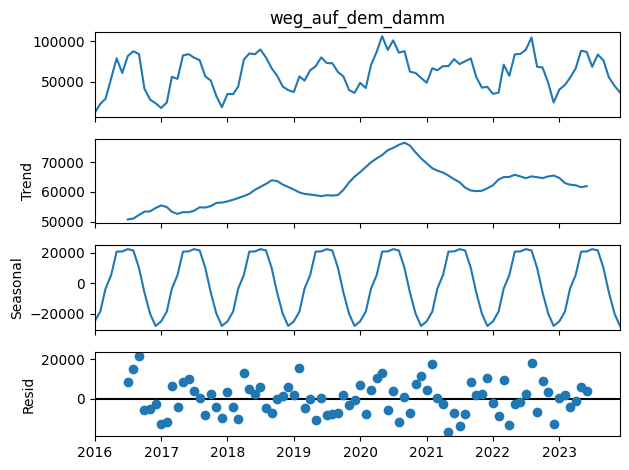

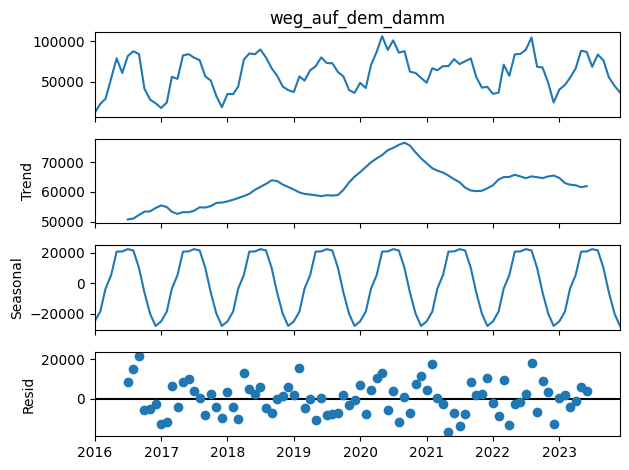

In [12]:
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [13]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -2.1965
p-value = 0.2075


In [14]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,weg_auf_dem_damm,scaled,log
year-month,,,,
2016-01-01,2016-01-01,11869,1.000000,0.000000
2016-02-01,2016-02-01,23015,12549.705378,9.437452
2016-03-01,2016-03-01,29352,19684.206184,9.887572
2016-04-01,2016-04-01,54468,47961.012598,10.778144
2016-05-01,2016-05-01,79024,75607.343951,11.233309
...,...,...,...,...
2023-08-01,2023-08-01,83681,80850.419579,11.300356
2023-09-01,2023-09-01,76247,72480.863166,11.191078
2023-10-01,2023-10-01,55518,49143.153334,10.802493


In [15]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [16]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -3.1530
P-value = 0.0229


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6988\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


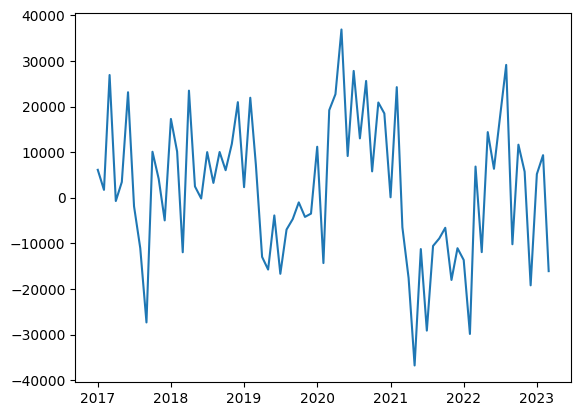

In [17]:
plt.plot(df_train['differences'])

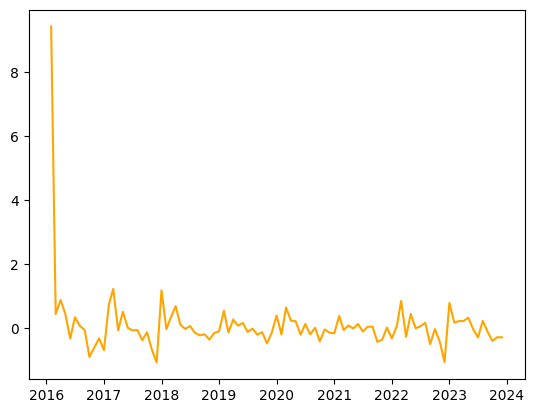

In [18]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [19]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -4.0209
P-value = 0.0013


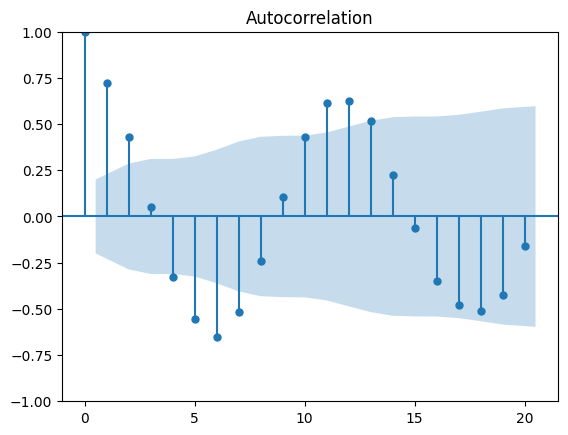

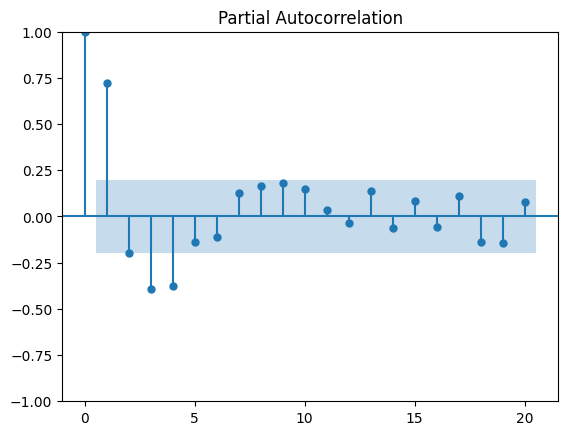

In [20]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [21]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,weg_auf_dem_damm,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,11869,1.000000,0.000000,NaN,1,8.891916,-8.891916
2016-02-01,2016-02-01,23015,12549.705378,9.437452,9.437452,2,10.288655,-0.851202
2016-03-01,2016-03-01,29352,19684.206184,9.887572,0.450119,3,10.738992,-0.851420
2016-04-01,2016-04-01,54468,47961.012598,10.778144,0.890572,4,11.004111,-0.225967
2016-05-01,2016-05-01,79024,75607.343951,11.233309,0.455165,5,11.278677,-0.045368
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,83681,80850.419579,11.300356,0.236662,8,11.287631,0.012725
2023-09-01,2023-09-01,76247,72480.863166,11.191078,-0.109278,9,11.119292,0.071785
2023-10-01,2023-10-01,55518,49143.153334,10.802493,-0.388585,10,10.803617,-0.001124


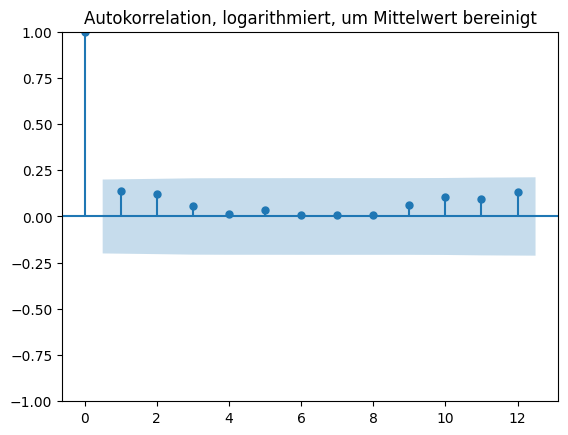

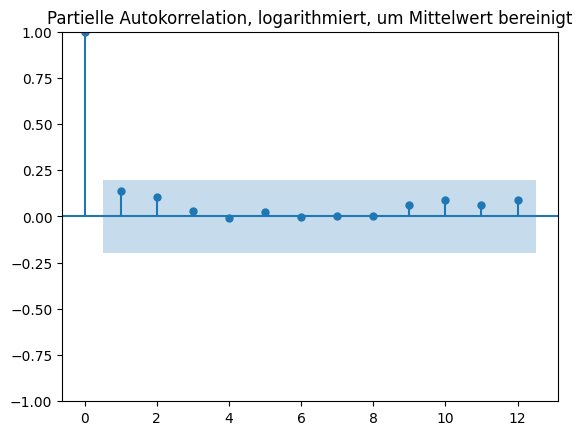

In [22]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

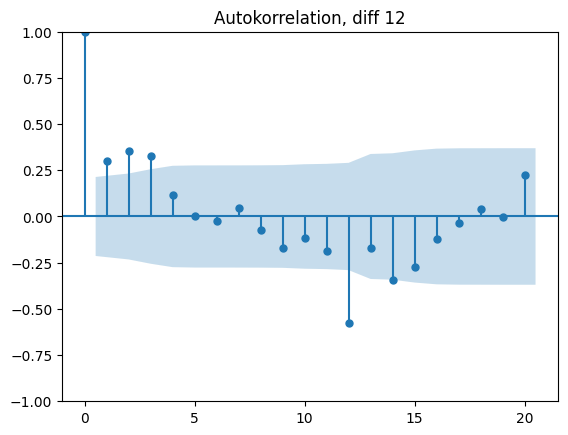

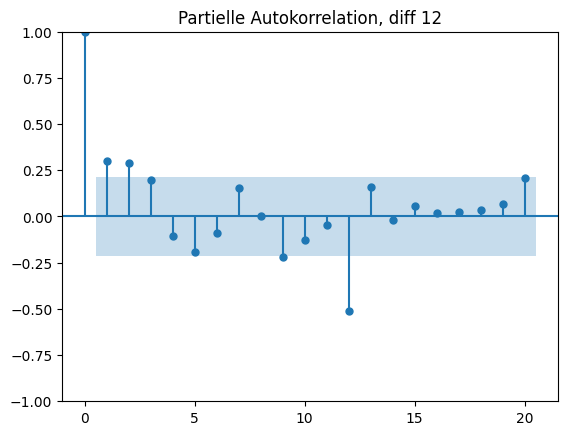

In [23]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [24]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(3, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 3, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(3,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(0,1,3,12) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -113.4879, AIC: 228.9758
ARIMA (0,1,0)x(0,1,0,12) LL -114.6117, AIC: 231.2235
ARIMA (1,0,0)x(0,1,1,12) LL -112.4726, AIC: 230.9452
ARIMA (1,0,0)x(0,1,2,12) LL -112.3250, AIC: 232.6500
ARIMA (1,1,0)x(0,1,2,12) LL -108.0632, AIC: 224.1264
ARIMA (0,0,1)x(0,1,2,12) LL -112.3374, AIC: 232.6748
ARIMA (0,1,1)x(0,1,2,12) LL -110.6260, AIC: 227.2520
ARIMA (0,1,1)x(2,1,0,12) LL -110.2632, AIC: 228.5264
ARIMA (0,1,1)x(3,1,0,12) LL -110.2593, AIC: 230.5185
ARIMA (0,1,1)x(0,1,3,12) LL -110.2133, AIC: 230.4267


In [25]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(0, 1, 1)x(0, 1, [2], 12)   Log Likelihood                -110.626
Date:                              Tue, 11 Feb 2025   AIC                            227.252
Time:                                      00:10:17   BIC                            234.164
Sample:                                  01-01-2016   HQIC                           230.009
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5890      0.070     -8.416      0.000      -0.726      -0.452
ma.S.L24       0.03

In [26]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean       unlogged    new_predict
2023-04-01       10.762905   47235.687046   53823.751980
2023-05-01       11.294409   80370.995154   83255.166061
2023-06-01       11.293362   80286.957562   83180.522265
2023-07-01       11.382174   87743.548739   89803.609089
2023-08-01       11.590950  108114.891180  107897.824867
2023-09-01       10.996621   59672.182400   64870.084891
2023-10-01       11.057802   63436.993622   68214.062187
2023-11-01       10.616101   40786.288180   48095.272619
2023-12-01        9.367127   11697.455983   22258.015796
2024-01-01       10.378902   32173.624560   40445.340151
2024-02-01       10.565922   38790.155226   46322.269171
2024-03-01       10.711440   44866.212452   51719.139350
2024-04-01       10.717460   45137.102605   51959.749163
2024-05-01       11.279514   79182.759635   82199.752558
2024-06-01       11.267213   78214.724290   81339.925060
2024-07-01       11.368453   86547.893538   88741.605284
2024-08-01       11.582267  107

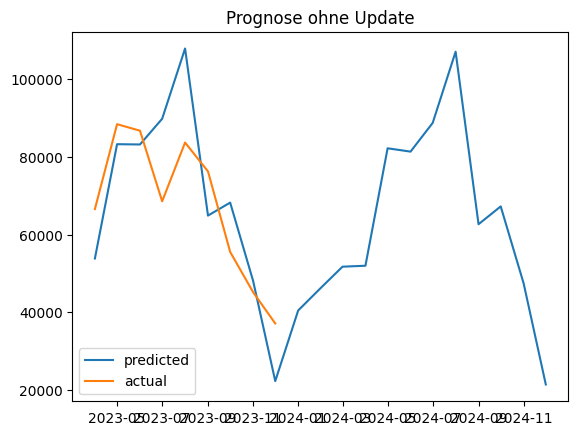

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6988\1951914538.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6988\1951914538.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel

mean absolute error (mae): ARIMA: 12082.0253
mean squared error (mse): ARIMA: 195428934.3395
mean absolute percentage error (mape): ARIMA: 0.1925


In [27]:
plt.plot(y_pred_no_update['new_predict'], label='predicted')
plt.plot(df_test_seas[header], label='actual')

plt.title('Prognose ohne Update')
plt.legend()
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [28]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.762905,47235.687046,53823.751980
2023-05-01,11.392176,88625.627222,90587.088060
2023-06-01,11.380748,87618.508309,89692.545790
2023-07-01,11.455218,94392.609645,95709.432091
2023-08-01,11.519523,100661.981483,101278.008004
2023-09-01,10.844323,51242.427262,57382.615233
2023-10-01,11.033455,61911.136263,66858.766512
2023-11-01,10.506530,36553.416577,44335.555145
2023-12-01,9.266886,10581.747406,21267.022109
2024-01-01,10.643050,41900.380172,49084.830423


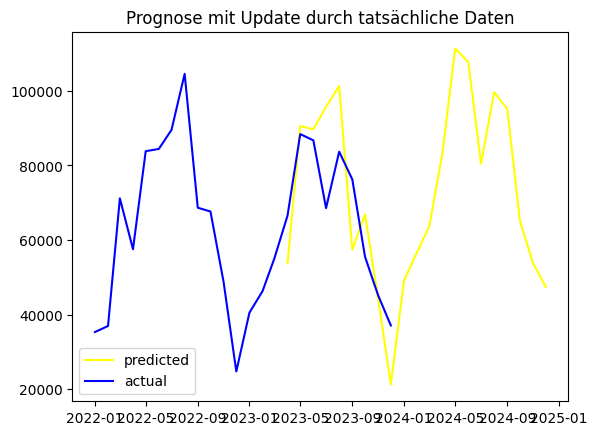

In [29]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [30]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 12167.5440
mean squared error (mse): ARIMA: 217653758.5761
mean absolute percentage error (mape): ARIMA: 0.1948
